In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [13]:
import torch.optim as optim
from tqdm import tqdm 
import matplotlib.pyplot as plt
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [5]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SemanticSegDataset(Dataset):
    def __init__(self, rgb_dir, mask_dir, rgb_transform=None, mask_transform=None):
        self.rgb_dir = rgb_dir
        self.mask_dir = mask_dir
        self.rgb_transform = rgb_transform
        self.mask_transform = mask_transform
        self.filenames = sorted(os.listdir(rgb_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        rgb_name = self.filenames[idx]
        rgb_path = os.path.join(self.rgb_dir, rgb_name)
        mask_name = rgb_name.replace("rgb", "semantic")
        mask_path = os.path.join(self.mask_dir, mask_name)

        rgb = Image.open(rgb_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.rgb_transform:
            rgb = self.rgb_transform(rgb)
        if self.mask_transform:
            mask = self.mask_transform(mask)

        return rgb, mask

In [6]:
import torchvision.transforms as T
from torch.utils.data import DataLoader

rgb_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

mask_transform = T.Compose([
    T.Resize((256, 256), interpolation=Image.NEAREST),
    T.PILToTensor(),  # Keeps integer labels
])

train_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/train/Semantic", rgb_transform, mask_transform)
val_dataset = SemanticSegDataset("/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/RGB", "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/val/Semantic", rgb_transform, mask_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# Data Analysis

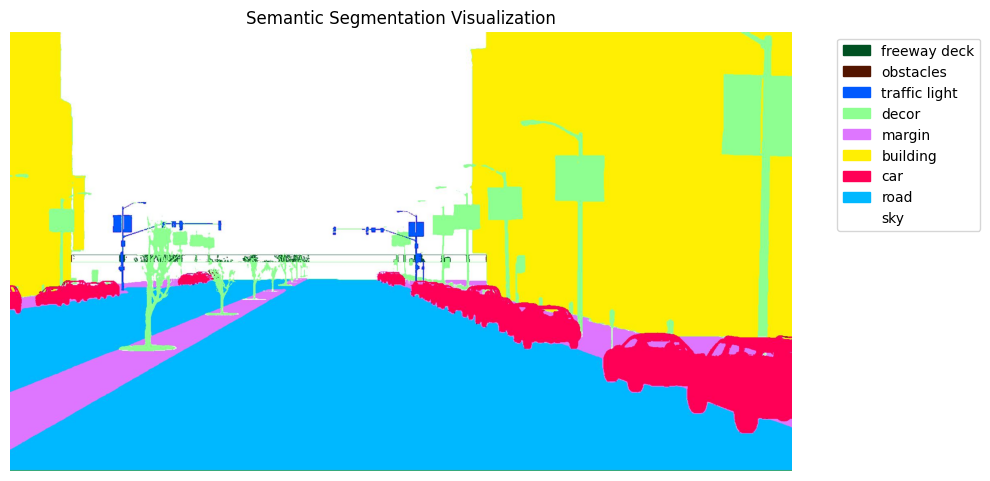

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import numpy as np

# === Your class color mapping ===
class_colors = {
    "freeway deck": [0, 81, 34],
    "obstacles": [83, 21, 0],
    "traffic light": [0, 89, 254], 
    "decor": [142, 255, 145],
    "margin": [222, 118, 255],
    "building": [255, 239, 3],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

# === Convert class_colors to RGB tuple format ===
color_to_label = {tuple(v): k for k, v in class_colors.items()}

# === Load the semantic segmentation image ===
semantic_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg"  # Replace with your path
semantic_image = Image.open(semantic_path).convert("RGB")
semantic_np = np.array(semantic_image)

# === Plot the image ===
plt.figure(figsize=(10, 10))
plt.imshow(semantic_np)
plt.axis("off")
plt.title("Semantic Segmentation Visualization")

# === Create legend patches ===
patches = [
    mpatches.Patch(color=np.array(rgb) / 255.0, label=label)
    for rgb, label in color_to_label.items()
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

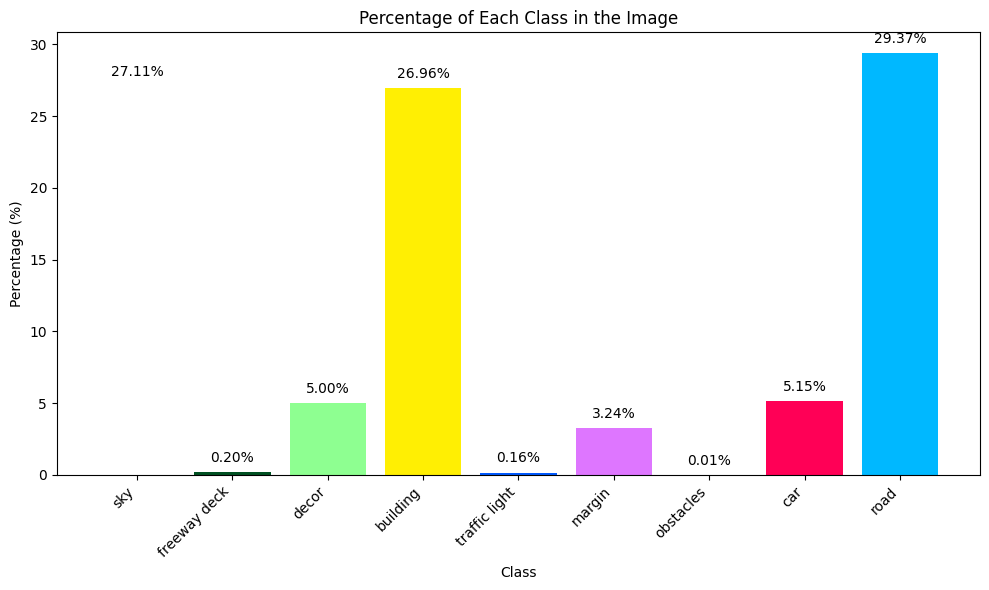

sky: 27.11%
freeway deck: 0.20%
decor: 5.00%
building: 26.96%
traffic light: 0.16%
margin: 3.24%
obstacles: 0.01%
car: 5.15%
road: 29.37%


In [8]:
import cv2
from collections import defaultdict
img = cv2.imread('/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg')
if img is None:
    raise FileNotFoundError("Image not found. Please check the file path.")

# Convert from BGR (OpenCV default) to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reshape the image to a list of pixels
pixels = img_rgb.reshape(-1, 3)

# Total number of pixels
total_pixels = pixels.shape[0]

# Initialize a dictionary to store the count of each class
class_counts = defaultdict(int)

# Tolerance for color matching (since exact matches are rare due to noise)
tolerance = 30

# Count pixels for each class
for pixel in pixels:
    for class_name, color in class_colors.items():
        color = np.array(color)
        if np.all(np.abs(pixel - color) <= tolerance):
            class_counts[class_name] += 1
            break

# Calculate percentages
percentages = {class_name: (count / total_pixels) * 100 for class_name, count in class_counts.items()}

# If some classes have 0%, include them in the plot
for class_name in class_colors.keys():
    if class_name not in percentages:
        percentages[class_name] = 0.0

# Plot the percentages
plt.figure(figsize=(10, 6))
bars = plt.bar(percentages.keys(), percentages.values(), color=[np.array(class_colors[name])/255 for name in percentages.keys()])
plt.xlabel('Class')
plt.ylabel('Percentage (%)')
plt.title('Percentage of Each Class in the Image')
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the percentages for reference
for class_name, percentage in percentages.items():
    print(f"{class_name}: {percentage:.2f}%")

In [9]:
color_to_class = {tuple(v): k for k, v in class_colors.items()}
semantic_folder = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic"

# Init pixel counter
class_pixel_counts = {cls: 0 for cls in class_colors}

# Get all image filenames
image_filenames = [f for f in os.listdir(semantic_folder) if f.endswith((".png", ".jpg"))]

# Loop with progress bar
for filename in tqdm(image_filenames, desc="Processing images"):
    image_path = os.path.join(semantic_folder, filename)
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    for color, class_name in color_to_class.items():
        mask = np.all(image_np == color, axis=-1)
        class_pixel_counts[class_name] += np.sum(mask)

# Normalize to percentage
total_pixels = sum(class_pixel_counts.values())
class_percentages = {
    cls: (count / total_pixels) * 100 for cls, count in class_pixel_counts.items()
}

# === Plot ===
plt.figure(figsize=(12, 6))
plt.bar(class_percentages.keys(), class_percentages.values(), color=[np.array(class_colors[c])/255 for c in class_colors])
plt.xticks(rotation=45)
plt.ylabel("Percentage of pixels (%)")
plt.title("Class Distribution in Training Semantic Images")
plt.tight_layout()
plt.show()

Processing images:   6%|▌         | 21/369 [00:12<03:19,  1.74it/s]


KeyboardInterrupt: 

# Training

In [10]:
import torchvision.models.segmentation as models
import torch.nn as nn
import torch

NUM_CLASSES = 10  # Change to your actual number of classes

model = models.deeplabv3_resnet50(weights="DEFAULT")
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:02<00:00, 77.8MB/s] 


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

# Train on 10 epochs

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True, min_lr=2e-6)

In [16]:
class EarlyStopping:
    def __init__(self, patience=20):
        self.patience = patience
        self.counter = 0
        self.best_acc = 0
        self.best_model_wts = None

    def step(self, acc, model):
        if acc > self.best_acc:
            self.best_acc = acc
            self.best_model_wts = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_model_wts:
            model.load_state_dict(self.best_model_wts)

early_stopping = EarlyStopping(patience=20)

In [21]:
class_colors = {
    "freeway deck": [0, 81, 33],
    "obstacles": [83, 21, 0],
    "traffic light": [0, 89, 254], 
    "decor": [142, 255, 145],
    "margin": [222, 118, 255],
    "building": [255, 239, 3],
    "car": [255, 0, 86],
    "road": [0, 184, 255],
    "sky": [255, 255, 255],
}

color_to_class = {tuple(rgb): idx for idx, (class_name, rgb) in enumerate(class_colors.items())}

def rgb_to_class_indices(batch_rgb_masks, color_to_class):
    batch_class_masks = []
    for rgb_mask in batch_rgb_masks:
        rgb_mask = rgb_mask.transpose(1, 2, 0)  # (C, H, W) to (H, W, C)
        class_mask = np.zeros(rgb_mask.shape[:2], dtype=np.int64)
        for color, class_idx in color_to_class.items():
            mask = np.all(rgb_mask == np.array(color), axis=-1)
            class_mask[mask] = class_idx
        batch_class_masks.append(torch.tensor(class_mask, dtype=torch.long))
    return torch.stack(batch_class_masks)

In [ ]:
def multiclass_dice_coef(preds, targets, num_classes, smooth=1e-6):
    preds = torch.argmax(preds, dim=1)  # shape: [B, H, W]
    dice = 0.0
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += (2. * intersection + smooth) / (union + smooth)
    return dice / num_classes


Validating: 100%|██████████| 93/93 [00:24<00:00,  3.79batch/s]


Epoch 1/30, Loss: 0.6224, Accuracy: 83.28%, Val Loss: 0.3709, Val Acc: 87.38%


Validating: 100%|██████████| 93/93 [00:18<00:00,  4.99batch/s]


Epoch 2/30, Loss: 0.3284, Accuracy: 88.36%, Val Loss: 0.2967, Val Acc: 88.86%


Validating: 100%|██████████| 93/93 [00:19<00:00,  4.88batch/s]


...

Epoch 28/30, Loss: 0.1290, Accuracy: 94.09%, Val Loss: 0.2653, Val Acc: 91.68%


Validating: 100%|██████████| 93/93 [00:18<00:00,  5.10batch/s]


Epoch 29/30, Loss: 0.1273, Accuracy: 94.17%, Val Loss: 0.2665, Val Acc: 91.60%


Validating: 100%|██████████| 93/93 [00:18<00:00,  5.02batch/s]


Epoch 30/30, Loss: 0.1288, Accuracy: 94.13%, Val Loss: 0.2608, Val Acc: 91.39%


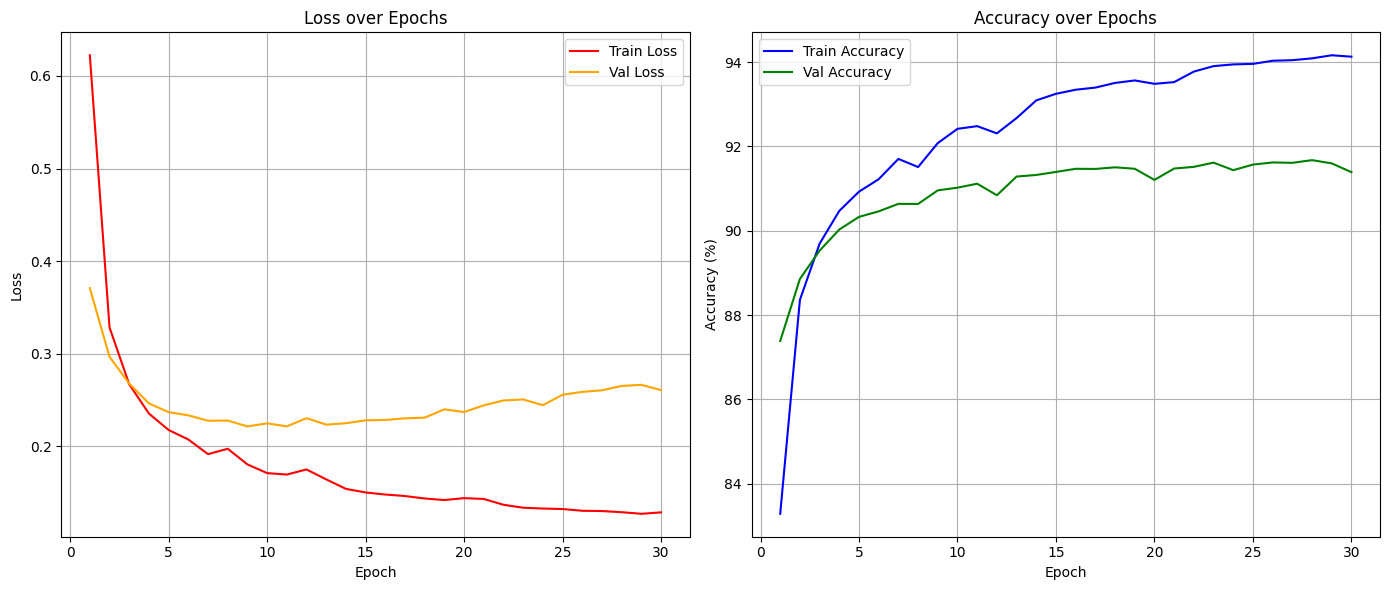

In [22]:
EPOCHS = 30
epoch_losses, epoch_accuracies, val_losses, val_accuracies = [], [], [], []

for epoch in range(EPOCHS):
    # -------- Training --------
    model.train()
    total_loss = 0
    total_correct = 0
    total_pixels = 0
    for images, rgb_masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", unit="batch"):
        images = images.to(device)
        masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class).to(device)

        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == masks).sum().item()
        total_pixels += masks.numel()

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = total_correct / total_pixels * 100
    epoch_losses.append(avg_train_loss)
    epoch_accuracies.append(train_accuracy)

    # -------- Validation --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, rgb_masks in tqdm(val_loader, desc="Validating", unit="batch"):
            images = images.to(device)
            masks = rgb_to_class_indices(rgb_masks.numpy(), color_to_class).to(device)

            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == masks).sum().item()
            val_total += masks.numel()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total * 100
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    # Scheduler and Early Stopping
    scheduler.step(val_accuracy)
    stop = early_stopping.step(val_accuracy, model)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

    if stop:
        print("Early stopping triggered.")
        break

early_stopping.restore(model)

# ---------------------------
# Plotting
# ---------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, label='Train Loss', color='red')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', color='orange')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(epoch_accuracies)+1), epoch_accuracies, label='Train Accuracy', color='blue')
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, label='Val Accuracy', color='green')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
import torch

# Save model weights
torch.save(model.state_dict(), 'deeplab_weights.pth')

# Test first 10 epochs

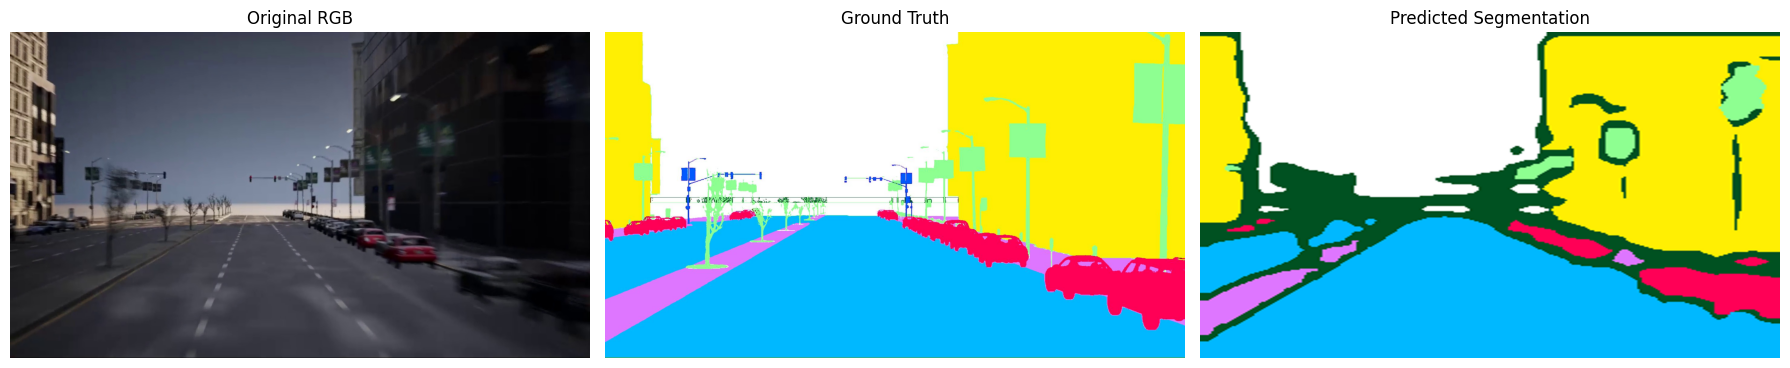

In [24]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

model.eval()

rgb_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/RGB/rgb_frame_1000.jpg"               # ← Update
gt_mask_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg" # ← Update

# Load RGB and GT mask
image = Image.open(rgb_path).convert("RGB")
gt_mask = Image.open(gt_mask_path).convert("RGB")
original_size = image.size

# Transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Process input image
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
model.eval()
with torch.no_grad():
    output = model(input_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# Decode prediction
def decode_segmentation(mask, class_colors):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, (class_name, color) in enumerate(class_colors.items()):
        color_mask[mask == idx] = color
    return color_mask

pred_color = decode_segmentation(pred, class_colors)
pred_image_resized = Image.fromarray(pred_color).resize(original_size)

# Plot
plt.figure(figsize=(18, 6))

# Original RGB
plt.subplot(1, 3, 1)
plt.title("Original RGB")
plt.imshow(image)
plt.axis("off")

# Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(gt_mask)
plt.axis("off")

# Predicted Segmentation
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation")
plt.imshow(pred_image_resized)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

model.eval()

rgb_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/RGB/rgb_frame_1000.jpg"               # ← Update
gt_mask_path = "/kaggle/input/ue-city-dataset/SyntheticData/SyntheticData/test/Semantic/semantic_frame_1000.jpg" # ← Update

# Load RGB and GT mask
image = Image.open(rgb_path).convert("RGB")
gt_mask = Image.open(gt_mask_path).convert("RGB")
original_size = image.size

# Transform
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Process input image
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
model.eval()
with torch.no_grad():
    output = model(input_tensor)['out']
    pred = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

# Decode prediction
def decode_segmentation(mask, class_colors):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    for idx, (class_name, color) in enumerate(class_colors.items()):
        color_mask[mask == idx] = color
    return color_mask

pred_color = decode_segmentation(pred, class_colors)
pred_image_resized = Image.fromarray(pred_color).resize(original_size)

# Plot
plt.figure(figsize=(18, 6))

# Original RGB
plt.subplot(1, 3, 1)
plt.title("Original RGB")
plt.imshow(image)
plt.axis("off")

# Ground Truth
plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(gt_mask)
plt.axis("off")

# Predicted Segmentation
plt.subplot(1, 3, 3)
plt.title("Predicted Segmentation")
plt.imshow(pred_image_resized)
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model.state_dict(), "segmentation_model_20epochs.pth")